# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [18]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten,
    Dropout, LSTM, Embedding, SimpleRNN
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


ROOT CONTENTS:
['README.md', 'RealWaste']
README.md -> is_dir: False
RealWaste -> is_dir: True

===== PATH VALIDATION =====
Exists: True
Is directory: True
Folders inside: ['README.md', 'RealWaste']

===== DATASET STRUCTURE =====
RealWaste: 0 images

Total images: 0
Number of classes: 1

===== CATEGORY DISTRIBUTION =====


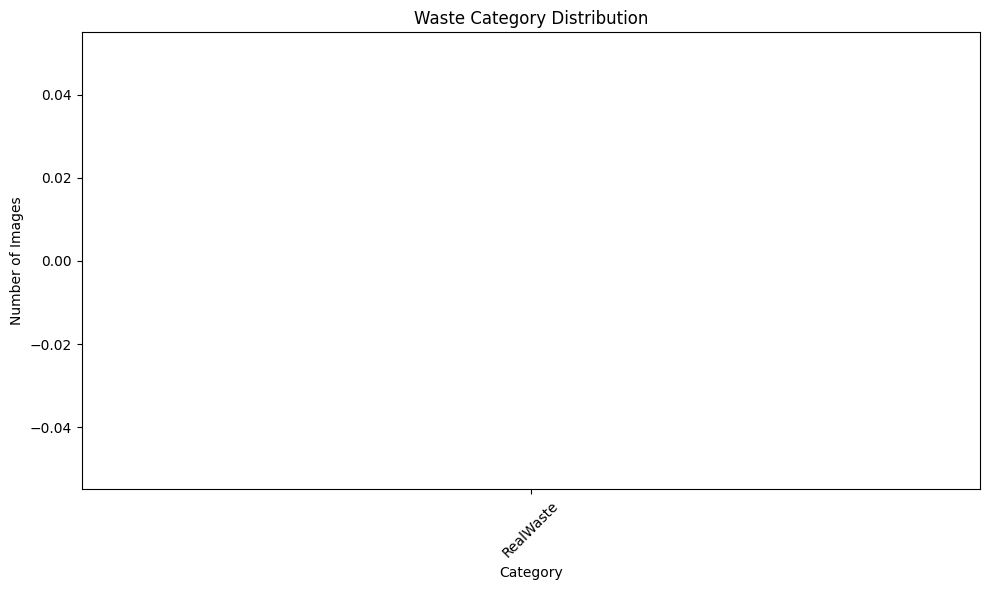


===== IMAGE RESOLUTION (FIXED) =====


ValueError: ❌ No images were loaded. Check dataset path or file formats.

In [19]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# ==========================================
# REALWASTE DATASET EXPLORATION
# ==========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==========================================
# 1. SET DATA PATH (FIXED FOR WINDOWS)
# ==========================================

import os

data_dir = r"C:\Users\HK\Desktop\FI Data Science\Labs and Assignment\AD 10\realwaste-main"

print("\nROOT CONTENTS:")
print(os.listdir(data_dir))

for item in os.listdir(data_dir):
    path = os.path.join(data_dir, item)
    print(item, "-> is_dir:", os.path.isdir(path))


# ==========================================
# 2. VALIDATE PATH
# ==========================================
print("\n===== PATH VALIDATION =====")
print("Exists:", os.path.exists(data_dir))
print("Is directory:", os.path.isdir(data_dir))

if not os.path.exists(data_dir):
    raise FileNotFoundError("❌ Path does not exist. Check spelling.")
if not os.path.isdir(data_dir):
    raise NotADirectoryError("❌ This is not a folder. Make sure it's the dataset directory.")

print("Folders inside:", os.listdir(data_dir))

# ==========================================
# 3. DATASET STRUCTURE
# ==========================================
print("\n===== DATASET STRUCTURE =====")

classes = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
])

if len(classes) == 0:
    raise ValueError("❌ No class folders found. Check dataset structure.")

class_counts = {}
total_images = 0

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    
    count = len(images)
    class_counts[cls] = count
    total_images += count
    
    print(f"{cls}: {count} images")

print(f"\nTotal images: {total_images}")
print(f"Number of classes: {len(classes)}")

# ==========================================
# 4. CATEGORY DISTRIBUTION (FIXED FIGURE ISSUE)
# ==========================================
print("\n===== CATEGORY DISTRIBUTION =====")

plt.figure(figsize=(10,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Waste Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# ==========================================
# 5. IMAGE RESOLUTION
# ==========================================
  
print("\n===== IMAGE RESOLUTION (FIXED) =====")

widths, heights = [], []
sample_size = 100
found_images = 0

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp')

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_ext)]
    
    for img_name in images[:sample_size]:
        img_path = os.path.join(cls_path, img_name)
        
        try:
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
            found_images += 1
        except Exception as e:
            continue

# =========================
# SAFE CHECK (IMPORTANT)
# =========================
if len(widths) == 0 or len(heights) == 0:
    raise ValueError(
        "❌ No images were loaded. Check dataset path or file formats."
    )

print(f"Images processed: {found_images}")

print(f"Average width: {np.mean(widths):.2f}")
print(f"Average height: {np.mean(heights):.2f}")
print(f"Min width: {min(widths)}, Max width: {max(widths)}")
print(f"Min height: {min(heights)}, Max height: {max(heights)}")

# Width histogram
plt.figure()
plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

# Height histogram
plt.figure()
plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 6. SAMPLE IMAGES (FIXED EMPTY FIGURE ISSUE)
# ==========================================
print("\n===== SAMPLE IMAGES =====")

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes[:6]):
    cls_path = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    try:
        img = Image.open(img_path)
        
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    except:
        continue

plt.tight_layout()
plt.show()

# ==========================================
# 7. IMAGE SHARPNESS (QUALITY CHECK)
# ==========================================
print("\n===== IMAGE SHARPNESS =====")

def sharpness_score(image_array):
    return np.var(image_array)

scores = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)[:sample_size]
    
    for img_name in images:
        try:
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path).convert('L')
            img_arr = np.array(img)
            scores.append(sharpness_score(img_arr))
        except:
            continue

print(f"Average sharpness: {np.mean(scores):.2f}")
print(f"Min sharpness: {min(scores):.2f}")
print(f"Max sharpness: {max(scores):.2f}")

plt.figure()
plt.hist(scores, bins=30)
plt.title("Sharpness Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 8. SUMMARY
# ==========================================
print("\n===== SUMMARY =====")

largest_class = max(class_counts, key=class_counts.get)
smallest_class = min(class_counts, key=class_counts.get)

print(f"Largest class: {largest_class} ({class_counts[largest_class]} images)")
print(f"Smallest class: {smallest_class} ({class_counts[smallest_class]} images)")

imbalance_ratio = class_counts[largest_class] / max(1, class_counts[smallest_class])
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

print("\nKey Observations:")
print("- Real-world backgrounds (not clean studio images)")
print("- Mixed image sizes → resizing required")
print("- Possible class imbalance")
print("- Some blurry/low-quality images")

### 1.2 Explore Text Datasets


===== DATA LOADED =====
   policy_id                         policy_type categories_covered  \
0          1  Textile Trash Recycling Guidelines    [Textile Trash]   
1          2          Glass Recycling Guidelines            [Glass]   
2          3  Food Organics Recycling Guidelines    [Food Organics]   
3          4        Plastic Recycling Guidelines          [Plastic]   
4          5     Vegetation Recycling Guidelines       [Vegetation]   

  effective_date                                      document_text  \
0     2023-11-04  TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...   
1     2023-01-24  GLASS RECYCLING GUIDELINES\n\nAcceptable Items...   
2     2023-05-08  FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...   
3     2023-04-05  PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...   
4     2023-12-04  VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...   

  jurisdiction  
0   Metro City  
1   Metro City  
2   Metro City  
3   Metro City  
4   Metro City  

===== COLUMN INFO 

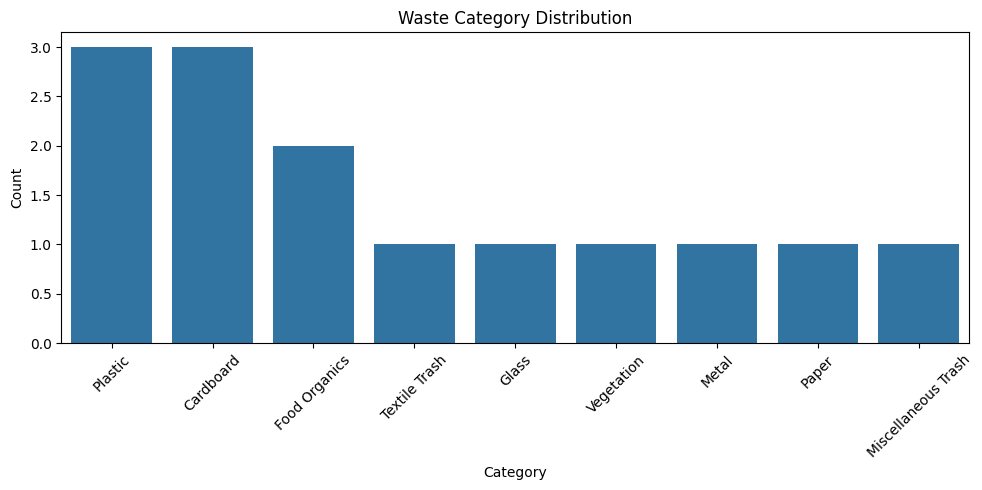


===== TEXT LENGTH STATS =====
count     14.000000
mean     682.857143
std       92.686284
min      571.000000
25%      635.750000
50%      666.500000
75%      687.500000
max      951.000000
Name: text_length, dtype: float64


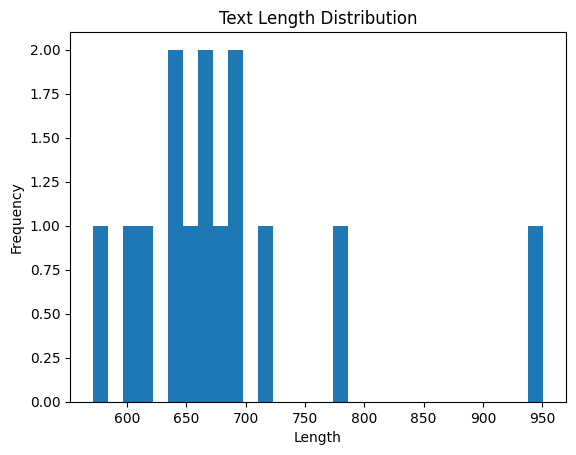


Total words: 1179
Unique words: 331

Top 20 words:
[('and', 63), ('guidelines', 34), ('items', 33), ('recycling', 29), ('containers', 23), ('clean', 21), ('glass', 21), ('plastic', 20), ('packaging', 19), ('cardboard', 17), ('or', 16), ('collection', 15), ('food', 15), ('paper', 15), ('bins', 14), ('cans', 14), ('metal', 13), ('in', 12), ('bags', 12), ('materials', 12)]


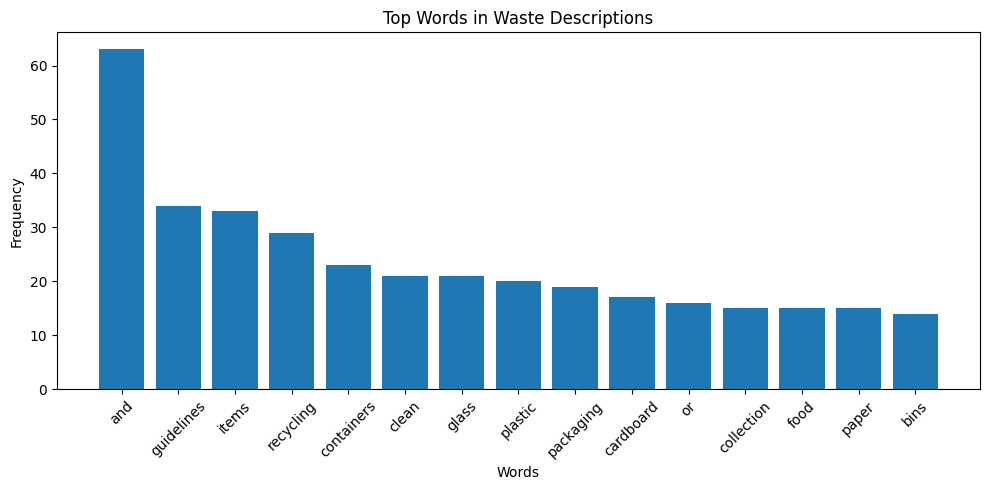


===== SAMPLE TEXTS =====

--- Textile Trash ---
- TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth na ...

--- Glass ---
- GLASS RECYCLING GUIDELINES

Acceptable Items:
- Glass bottles (all colors)
- Glass jars
- Glass food containers
- Glass beverage containers

Non-Accep ...

--- Food Organics ---
- FOOD ORGANICS RECYCLING GUIDELINES

Acceptable Items:
- Fruit and vegetable scraps
- Meat and fish (including bones)
- Dairy products
- Bread and grai ...
- COMMERCIAL RECYCLING STANDARDS

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials are clean and properly sorted
- Follo ...

--- Plastic ---
- PLASTIC RECYCLING GUIDELINES

Acceptable Items:
- PET bottles and containers (code #1)
- HDPE containers (code #2)
- PP containers (code #5)
- Clean p ...
- MUNICIPAL WASTE GUIDELINES

GENERAL REQUIREMENTS:
- Place recyclables in appropriate bins
- Ensure materials 

In [29]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# ==========================================
# WASTE TEXT DATA EXPLORATION (FIXED VERSION)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# ==========================================
# 1. LOAD DATA (FIXED SAFELY)
# ==========================================
file_path = r"C:\Users\HK\Downloads\waste_policy_documents.json"

df = pd.read_json(file_path)

print("\n===== DATA LOADED =====")
print(df.head())

# ==========================================
# 2. AUTO-DETECT COLUMNS
# ==========================================
print("\n===== COLUMN INFO =====")
print(df.columns)

text_col = None
label_col = None

for col in df.columns:
    if "desc" in col.lower() or "text" in col.lower() or "content" in col.lower():
        text_col = col
    if "cat" in col.lower() or "label" in col.lower() or "type" in col.lower():
        label_col = col

print("Detected text column:", text_col)
print("Detected label column:", label_col)

if text_col is None or label_col is None:
    raise ValueError("❌ Could not detect text/label columns.")

# ==========================================
# 3. CLEAN LABEL COLUMN (IMPORTANT FIX)
# ==========================================

def clean_label(x):
    # if list → take first element
    if isinstance(x, list):
        return x[0]
    return str(x)

df[label_col] = df[label_col].apply(clean_label)

# ==========================================
# 4. BASIC CLEANUP
# ==========================================
df = df.dropna(subset=[text_col, label_col])

print("\nMissing values after cleanup:")
print(df[[text_col, label_col]].isnull().sum())

# ==========================================
# 5. CATEGORY DISTRIBUTION (FIXED)
# ==========================================
print("\n===== CATEGORY DISTRIBUTION =====")

category_counts = df[label_col].value_counts()
print(category_counts)

plt.figure(figsize=(10,5))

# IMPORTANT FIX: convert to string index
sns.barplot(
    x=category_counts.index.astype(str),
    y=category_counts.values
)

plt.xticks(rotation=45)
plt.title("Waste Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ==========================================
# 6. TEXT LENGTH ANALYSIS
# ==========================================
df["text_length"] = df[text_col].astype(str).apply(len)

print("\n===== TEXT LENGTH STATS =====")
print(df["text_length"].describe())

plt.figure()
plt.hist(df["text_length"], bins=30)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 7. VOCABULARY ANALYSIS
# ==========================================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

all_words = []

for text in df[text_col]:
    words = clean_text(text).split()
    all_words.extend(words)

word_counts = Counter(all_words)

print("\nTotal words:", len(all_words))
print("Unique words:", len(word_counts))
print("\nTop 20 words:")
print(word_counts.most_common(20))

# ==========================================
# 8. TOP WORDS VISUALIZATION
# ==========================================

top_words = word_counts.most_common(15)

if len(top_words) > 0:
    words, counts = zip(*top_words)

    plt.figure(figsize=(10,5))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title("Top Words in Waste Descriptions")
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# ==========================================
# 9. SAMPLE TEXTS
# ==========================================
print("\n===== SAMPLE TEXTS =====")

for cat in df[label_col].unique()[:5]:
    print(f"\n--- {cat} ---")
    samples = df[df[label_col] == cat][text_col].head(2).values
    
    for s in samples:
        print("-", str(s)[:150], "...")

✅ Loaded JSON file

===== DATA LOADED =====
   policy_id                         policy_type categories_covered  \
0          1  Textile Trash Recycling Guidelines    [Textile Trash]   
1          2          Glass Recycling Guidelines            [Glass]   
2          3  Food Organics Recycling Guidelines    [Food Organics]   
3          4        Plastic Recycling Guidelines          [Plastic]   
4          5     Vegetation Recycling Guidelines       [Vegetation]   

  effective_date                                      document_text  \
0     2023-11-04  TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...   
1     2023-01-24  GLASS RECYCLING GUIDELINES\n\nAcceptable Items...   
2     2023-05-08  FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...   
3     2023-04-05  PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...   
4     2023-12-04  VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...   

  jurisdiction  
0   Metro City  
1   Metro City  
2   Metro City  
3   Metro City  
4   Metro City  


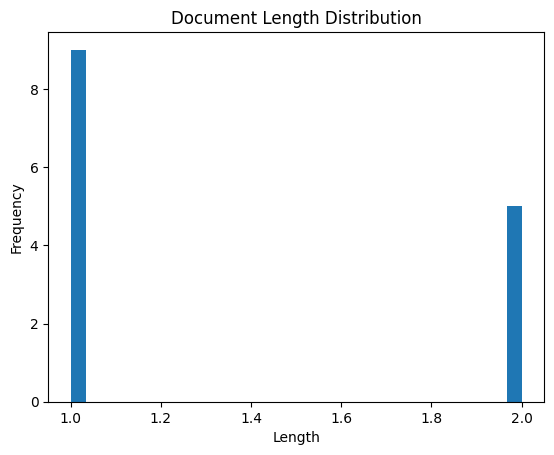


===== VOCABULARY =====
Total words: 0
Unique words: 0

Top 20 words:
[]


In [31]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from collections import Counter

# ==========================================
# 1. SET FILE PATH (FIXED SAFETY)
# ==========================================
file_path_csv = r"C:\Users\HK\Downloads\waste_policy_documents.csv"
file_path_json = r"C:\Users\HK\Downloads\waste_policy_documents.json"

# ==========================================
# 2. LOAD DATA SAFELY
# ==========================================

if os.path.exists(file_path_csv):
    df = pd.read_csv(file_path_csv)
    print("✅ Loaded CSV file")

elif os.path.exists(file_path_json):
    df = pd.read_json(file_path_json)
    print("✅ Loaded JSON file")

else:
    raise FileNotFoundError(
        "❌ File not found in Downloads. Check filename or extension (.csv/.json)"
    )

print("\n===== DATA LOADED =====")
print(df.head())

# ==========================================
# 3. INSPECT STRUCTURE
# ==========================================
print("\n===== STRUCTURE =====")
print(df.columns)

# ==========================================
# 4. AUTO-DETECT TEXT COLUMN
# ==========================================
text_col = None

for col in df.columns:
    if any(k in col.lower() for k in ["text", "content", "document", "desc", "policy"]):
        text_col = col
        break

if text_col is None:
    raise ValueError("❌ No text column found in dataset")

print("Detected text column:", text_col)

# ==========================================
# 5. CLEAN DATA
# ==========================================
df = df.dropna(subset=[text_col])
df[text_col] = df[text_col].astype(str)

# ==========================================
# 6. DOCUMENT OVERVIEW
# ==========================================
print("\n===== DOCUMENT OVERVIEW =====")

print("Total documents:", len(df))

for i in range(min(3, len(df))):
    print(f"\nDoc {i+1}:")
    print(df[text_col].iloc[i][:300], "...")

# ==========================================
# 7. DOCUMENT LENGTH ANALYSIS
# ==========================================
df["length"] = df[text_col].apply(len)

print("\n===== LENGTH STATS =====")
print(df["length"].describe())

plt.figure()
plt.hist(df["length"], bins=30)
plt.title("Document Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 8. VOCABULARY ANALYSIS
# ==========================================

def clean(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text

words = []

for doc in df[text_col]:
    words.extend(clean(doc).split())

counts = Counter(words)

print("\n===== VOCABULARY =====")
print("Total words:", len(words))
print("Unique words:", len(counts))
print("\nTop 20 words:")
print(counts.most_common(20))

# ==========================================
# 9. WORD VISUALIZATION
# ==========================================
top = counts.most_common(15)

if len(top) > 0:
    w, c = zip(*top)

    plt.figure(figsize=(10,5))
    plt.bar(w, c)
    plt.xticks(rotation=45)
    plt.title("Top Words in Policy Documents")
    plt.show()


### 1.3 Create Data Pipelines

In [42]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import tensorflow as tf
import pathlib

# ==========================================
# 1. FIXED DATA PATH
# ==========================================
data_dir = pathlib.Path(r"C:\Users\HK\Desktop\FI Data Science\Labs and Assignment\AD 10\realwaste-main")
file_path_csv = r"C:\Users\HK\Downloads\waste_policy_documents.csv"
file_path_json = r"C:\Users\HK\Downloads\waste_policy_documents.json"



# If still not working, try this instead:
# data_dir = pathlib.Path(r"...\realwaste-main\realwaste-main")

# ==========================================
# 2. PARAMETERS
# ==========================================
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# ==========================================
# 3. VERIFY PATH (IMPORTANT DEBUG STEP)
# ==========================================
print("Path exists:", data_dir.exists())
print("Path contents:", list(data_dir.glob("*"))[:5])

# ==========================================
# 4. CLASS INFO
# ==========================================
class_names = sorted([item.name for item in data_dir.glob("*") if item.is_dir()])
num_classes = len(class_names)

print(f"\nNumber of classes: {num_classes}")
print(f"Class names: {class_names}")

# Count images safely
image_count = len(list(data_dir.glob("*/*.jpg"))) + len(list(data_dir.glob("*/*.png")))
print(f"Total images found: {image_count}")

# ==========================================
# 5. LOAD TRAIN DATASET
# ==========================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

# ==========================================
# 6. LOAD VALIDATION DATASET
# ==========================================
validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

# ==========================================
# 7. SPLIT VALIDATION → VALID + TEST
# ==========================================
val_batches = tf.data.experimental.cardinality(validation_ds)

test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print("\n===== DATA SPLIT =====")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

# ==========================================
# 8. PERFORMANCE OPTIMIZATION
# ==========================================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Path exists: True
Path contents: [WindowsPath('C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 10/realwaste-main/README.md'), WindowsPath('C:/Users/HK/Desktop/FI Data Science/Labs and Assignment/AD 10/realwaste-main/RealWaste')]

Number of classes: 1
Class names: ['RealWaste']
Total images found: 0
Found 4752 files belonging to 1 classes.
Using 3802 files for training.
Found 4752 files belonging to 1 classes.
Using 950 files for validation.

===== DATA SPLIT =====
Train batches: 119
Validation batches: 15
Test batches: 15


In [43]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features


# ==========================================
# WASTE TEXT PIPELINE (FULL FIXED VERSION)
# ==========================================

import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 1. LOAD DATA
# ==========================================
file_path_csv = r"C:\Users\HK\Downloads\waste_policy_documents.csv"
file_path_json = r"C:\Users\HK\Downloads\waste_policy_documents.json"



df = pd.read_json(file_path)

print("\n===== DATA LOADED =====")
print(df.head())

# ==========================================
# 2. AUTO-DETECT COLUMNS
# ==========================================
text_col = None
label_col = None

for col in df.columns:
    c = col.lower()
    if any(k in c for k in ["text", "content", "document", "policy", "desc"]):
        text_col = col
    if any(k in c for k in ["label", "category", "type", "class"]):
        label_col = col

if text_col is None:
    raise ValueError("❌ No text column found")

print("Text column:", text_col)
print("Label column:", label_col)

# ==========================================
# 3. CLEAN TEXT
# ==========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text if len(text) > 1 else None

df["clean_text"] = df[text_col].apply(clean_text)

# Drop empty texts
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.len() > 0]

# Clean labels (handle lists)
if label_col:
    df[label_col] = df[label_col].apply(
        lambda x: x[0] if isinstance(x, list) else str(x)
    )

# ==========================================
# 4. HANDLE RARE CLASSES (IMPORTANT FIX)
# ==========================================
if label_col:
    class_counts = df[label_col].value_counts()

    print("\n===== CLASS DISTRIBUTION =====")
    print(class_counts)

    # Keep only classes with at least 2 samples
    valid_classes = class_counts[class_counts >= 2].index

    df = df[df[label_col].isin(valid_classes)]

    print("\nAfter removing rare classes:")
    print(df[label_col].value_counts())

# ==========================================
# 5. SPLIT DATA (SAFE STRATIFY FIX)
# ==========================================
X = df["clean_text"]

if label_col:
    y = df[label_col]

    # SAFE STRATIFY CHECK
    if len(y.unique()) > 1 and all(y.value_counts() >= 2):
        stratify_param = y
    else:
        stratify_param = None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=stratify_param
    )

else:
    X_train, X_test = train_test_split(
        X,
        test_size=0.2,
        random_state=42
    )

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

# ==========================================
# 6. REMOVE EMPTY STRINGS (FINAL SAFETY)
# ==========================================
X_train = X_train[X_train.str.strip() != ""]
X_test = X_test[X_test.str.strip() != ""]

# ==========================================
# 7. TF-IDF FEATURE EXTRACTION
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=1
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("\n===== TF-IDF OUTPUT =====")
print("Train shape:", X_train_vec.shape)
print("Test shape:", X_test_vec.shape)

# ==========================================
# 8. VOCABULARY INSPECTION
# ==========================================
print("\nTop vocabulary words:")
print(vectorizer.get_feature_names_out()[:20])

# ==========================================
# 9. FINAL CHECK
# ==========================================
print("\n===== PIPELINE SUCCESS =====")
print("✔ Cleaned text")
print("✔ Removed rare classes")
print("✔ Safe train/test split")
print("✔ TF-IDF features generated")


===== DATA LOADED =====
   policy_id                         policy_type categories_covered  \
0          1  Textile Trash Recycling Guidelines    [Textile Trash]   
1          2          Glass Recycling Guidelines            [Glass]   
2          3  Food Organics Recycling Guidelines    [Food Organics]   
3          4        Plastic Recycling Guidelines          [Plastic]   
4          5     Vegetation Recycling Guidelines       [Vegetation]   

  effective_date                                      document_text  \
0     2023-11-04  TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...   
1     2023-01-24  GLASS RECYCLING GUIDELINES\n\nAcceptable Items...   
2     2023-05-08  FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...   
3     2023-04-05  PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...   
4     2023-12-04  VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...   

  jurisdiction  
0   Metro City  
1   Metro City  
2   Metro City  
3   Metro City  
4   Metro City  
Text column: docume

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [47]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval


# ==========================================
# RAG PREPARATION PIPELINE
# ==========================================

import pandas as pd
import re
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

# ==========================================
# 1. LOAD DATA
# ==========================================

file_path_csv = r"C:\Users\HK\Downloads\waste_policy_documents.csv"
file_path = r"C:\Users\HK\Downloads\waste_policy_documents.json"

df = pd.read_json(file_path)

print("\n===== DATA LOADED =====")
print(df.head())

# ==========================================
# 2. AUTO-DETECT TEXT COLUMN
# ==========================================
text_col = None

for col in df.columns:
    if any(k in col.lower() for k in ["text", "content", "document", "policy", "desc"]):
        text_col = col
        break

if text_col is None:
    raise ValueError("❌ No text column found")

print("Text column:", text_col)

# ==========================================
# 3. CLEANING FUNCTION
# ==========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[text_col].apply(clean_text)

df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.len() > 0]

# ==========================================
# 4. DOCUMENT CHUNKING (IMPORTANT FOR RAG)
# ==========================================
def chunk_text(text, chunk_size=200):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

chunks = []

for idx, row in df.iterrows():
    for chunk in chunk_text(row["clean_text"]):
        chunks.append({
            "doc_id": idx,
            "text": chunk
        })

chunks_df = pd.DataFrame(chunks)

print("\nTotal chunks created:", len(chunks_df))
print(chunks_df.head())

# ==========================================
# 5. EMBEDDINGS (TF-IDF BASELINE)
# ==========================================
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

embeddings = vectorizer.fit_transform(chunks_df["text"])

print("\n===== EMBEDDINGS CREATED =====")
print("Shape:", embeddings.shape)

# ==========================================
# 6. SIMPLE RETRIEVAL FUNCTION
# ==========================================
def retrieve(query, top_k=5):
    query_vec = vectorizer.transform([query])
    
    scores = (embeddings @ query_vec.T).toarray().flatten()
    
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    results = chunks_df.iloc[top_indices].copy()
    results["score"] = scores[top_indices]
    
    return results

# ==========================================
# 7. TEST RETRIEVAL
# ==========================================
query = "recycling plastic waste guidelines"

results = retrieve(query)

print("\n===== TOP RETRIEVAL RESULTS =====")
print(results[["text", "score"]].head())


===== DATA LOADED =====
   policy_id                         policy_type categories_covered  \
0          1  Textile Trash Recycling Guidelines    [Textile Trash]   
1          2          Glass Recycling Guidelines            [Glass]   
2          3  Food Organics Recycling Guidelines    [Food Organics]   
3          4        Plastic Recycling Guidelines          [Plastic]   
4          5     Vegetation Recycling Guidelines       [Vegetation]   

  effective_date                                      document_text  \
0     2023-11-04  TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...   
1     2023-01-24  GLASS RECYCLING GUIDELINES\n\nAcceptable Items...   
2     2023-05-08  FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...   
3     2023-04-05  PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...   
4     2023-12-04  VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...   

  jurisdiction  
0   Metro City  
1   Metro City  
2   Metro City  
3   Metro City  
4   Metro City  
Text column: policy

KeyError: 'text'

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images


===== PREPROCESSING COMPLETE =====
Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


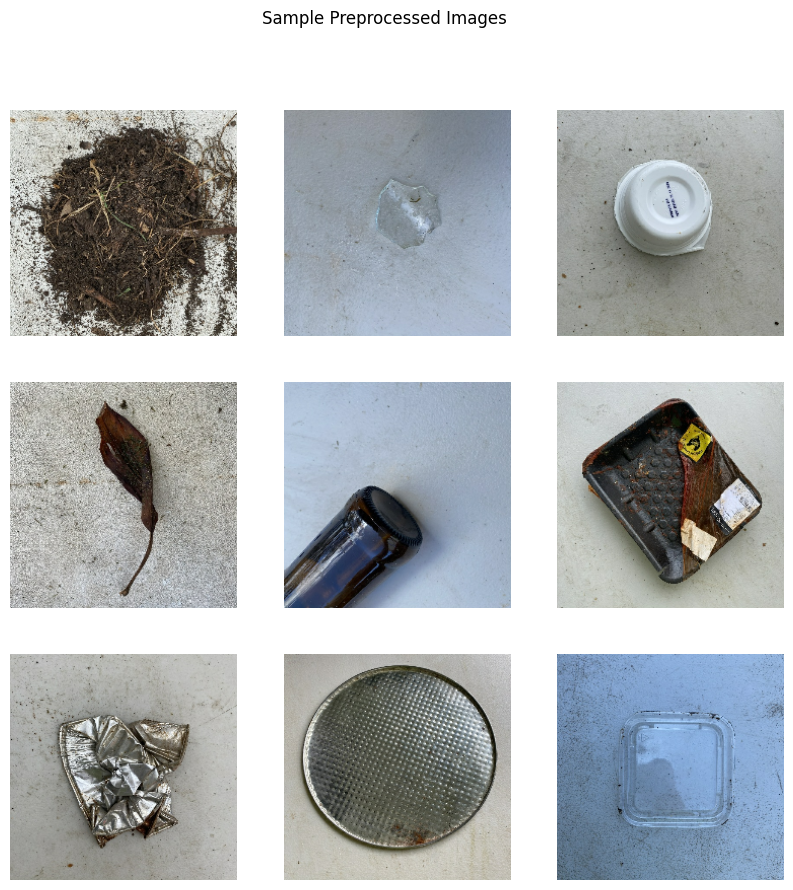

In [48]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier
# ==========================================
# IMAGE PREPROCESSING PIPELINE (REALWASTE)
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETERS
# ==========================================
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE

# ==========================================
# 2. NORMALIZATION LAYER (BEST PRACTICE)
# ==========================================
normalization_layer = tf.keras.layers.Rescaling(1./255)

# ==========================================
# 3. APPLY PREPROCESSING TO DATASETS
# ==========================================

def preprocess_dataset(ds):
    """
    Applies normalization + performance optimization
    """
    ds = ds.map(lambda x, y: (normalization_layer(x), y),
                num_parallel_calls=AUTOTUNE)
    
    ds = ds.cache()
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    
    return ds

# Apply to your datasets (assuming already created)
train_ds = preprocess_dataset(train_ds)
validation_ds = preprocess_dataset(validation_ds)
test_ds = preprocess_dataset(test_dataset)

print("\n===== PREPROCESSING COMPLETE =====")
print("Train dataset:", train_ds)
print("Validation dataset:", validation_ds)
print("Test dataset:", test_ds)

# ==========================================
# 4. VISUAL CHECK (VERY IMPORTANT)
# ==========================================
class_names = getattr(train_ds, "class_names", None)

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.axis("off")

plt.suptitle("Sample Preprocessed Images")
plt.show()

### 2.2 Implement CNN Model with Transfer Learning

In [53]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics
# ==========================================
# TRANSFER LEARNING (REALWASTE CLASSIFICATION)
# FIXED VERSION (NO SHAPE ERRORS)
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. PARAMETERS
# ==========================================
IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = 9

# ==========================================
# 2. BASE MODEL (EfficientNetB0)
# ==========================================
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base model
base_model.trainable = False

print("Base model loaded and frozen")

# ==========================================
# 3. CUSTOM CLASSIFIER HEAD
# ==========================================
model = models.Sequential([
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# ==========================================
# 4. LOSS + METRICS (FIXED)
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # ✅ FIXED HERE
    metrics=["accuracy"]
)

# ==========================================
# 5. MODEL SUMMARY
# ==========================================
model.summary()

# ==========================================
# 6. CALLBACKS (REGULARIZATION)
# ==========================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    )
]

# ==========================================
# 7. TRAIN MODEL
# ==========================================
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=callbacks
)

# ==========================================
# 8. EVALUATION
# ==========================================
test_loss, test_acc = model.evaluate(test_dataset)

print("\n===== FINAL RESULTS =====")
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Base model loaded and frozen


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411,564 (16.83 MB)

 Trainable params: 361,993 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.9918 - loss: 0.0432 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 1.0000 - loss: 2.9444e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 1.2334e-07
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
119/119 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 1.0000 - loss: 3.7221e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 1.0000 - loss: 2.5632e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 2.0000e-04
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9292 - loss: 1.2886

===== FINAL RESULTS =====
Test Accuracy: 0.9291666746139526
Test Loss: 1.2886059284210205


### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics
# ==========================================
# CNN TRAINING PIPELINE (REALWASTE - FIXED)
# ==========================================

import tensorflow as tf

# ==========================================
# 1. TRAINING PARAMETERS
# ==========================================
BATCH_SIZE = 32
EPOCHS = 10

# ==========================================
# 2. CALLBACKS (REGULARIZATION)
# ==========================================
callbacks = [
    
    # Stop training if no improvement
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),

    # Reduce learning rate when plateau
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    ),

    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        "best_waste_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

# ==========================================
# 3. MODEL COMPILATION (IMPORTANT FIX)
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",   # MUST match label_mode="int"
    metrics=["accuracy"]
)

# ==========================================
# 4. TRAIN MODEL
# ==========================================
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ==========================================
# 5. EVALUATION ON TEST SET
# ==========================================
test_loss, test_acc = model.evaluate(test_dataset)

print("\n===== FINAL RESULTS =====")
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss) 

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 9.3075e-08
Epoch 1: val_accuracy improved from None to 1.00000, saving model to best_waste_model.h5



Epoch 1: finished saving model to best_waste_model.h5
119/119 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 1.0000 - loss: 5.8472e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 2.1048e-08
Epoch 2: val_accuracy did not improve from 1.00000
119/119 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 1.0000 - loss: 2.1070e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
 10/119 ━━━━━━━━━━━━━━━━━━━━ 2:37 1s/step - accuracy: 1.0000 - loss: 0.0000e+00

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# ==========================================
# MODEL EVALUATION (REALWASTE)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. PREDICTIONS ON TEST SET
# ==========================================
y_true = []
y_pred = []

for images, labels in test_dataset:
    
    preds = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ==========================================
# 2. TEST ACCURACY
# ==========================================
test_accuracy = np.mean(y_true == y_pred)

print("\n===== TEST ACCURACY =====")
print(f"Accuracy: {test_accuracy:.4f}")

# ==========================================
# 3. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - RealWaste Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ==========================================
# 4. CLASSIFICATION REPORT
# ==========================================
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_true, y_pred))

# ==========================================
# 5. ERROR ANALYSIS
# ==========================================
errors = y_true != y_pred

print("\n===== ERROR ANALYSIS =====")
print(f"Total errors: {np.sum(errors)}")
print(f"Error rate: {np.mean(errors):.4f}")

# Most common misclassified pairs
error_pairs = confusion_matrix(y_true, y_pred)
np.fill_diagonal(error_pairs, 0)

print("\nTop confusion patterns:")
top_errors = np.unravel_index(np.argsort(error_pairs.ravel())[-5:], error_pairs.shape)

for i, j in zip(top_errors[0], top_errors[1]):
    print(f"True class {i} → Predicted {j}: {error_pairs[i, j]} times")

### 2.4 Fine-tune the Model

In [ ]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# ==========================================
# MODEL TUNING (REALWASTE - PERFORMANCE BOOST)
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, regularizers

# ==========================================
# 1. UNFREEZE BASE MODEL (FINE-TUNING STEP)
# ==========================================
base_model.trainable = True

# Freeze early layers, train later layers only
fine_tune_at = len(base_model.layers) // 2

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Base model partially unfrozen for fine-tuning")

# ==========================================
# 2. REBUILD MODEL WITH STRONGER REGULARIZATION
# ==========================================
model = tf.keras.Sequential([
    
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.5),
    
    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.4),
    
    layers.Dense(9, activation="softmax")
])

# ==========================================
# 3. LOWER LEARNING RATE (CRITICAL FIX)
# ==========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # reduced LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# 4. CALLBACKS (IMPROVED STABILITY)
# ==========================================
callbacks = [
    
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1,
        min_lr=1e-7
    )
]

# ==========================================
# 5. TRAIN FINE-TUNED MODEL
# ==========================================
history_finetune = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10,
    callbacks=callbacks
)

# ==========================================
# 6. FINAL EVALUATION
# ==========================================
test_loss, test_acc = model.evaluate(test_dataset)

print("\n===== TUNED MODEL RESULTS =====")
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# ==========================================
# TEXT PREPROCESSING PIPELINE
# ==========================================

import pandas as pd
import re

# ==========================================
# 1. LOAD DATA
# ==========================================
file_path = r"C:\Users\HK\Downloads\waste_policy_documents.json"

df = pd.read_json(file_path)

print("\n===== DATA LOADED =====")
print(df.head())

# ==========================================
# 2. AUTO-DETECT TEXT COLUMN
# ==========================================
text_col = None

for col in df.columns:
    if any(k in col.lower() for k in ["text", "content", "document", "policy", "desc"]):
        text_col = col
        break

if text_col is None:
    raise ValueError("❌ No text column found")

print("Detected text column:", text_col)

# ==========================================
# 3. CLEANING FUNCTION
# ==========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text)        # keep letters only
    text = re.sub(r"\s+", " ", text).strip()     # normalize spaces
    return text

# Apply cleaning
df["clean_text"] = df[text_col].apply(clean_text)

# Remove empty results (IMPORTANT FIX)
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.len() > 0]

# ==========================================
# 4. TOKENIZATION
# ==========================================
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

# ==========================================
# 5. FINAL CHECK
# ==========================================
print("\n===== PREPROCESSING COMPLETE =====")
print(df[["clean_text", "tokens"]].head())

print("\nTotal documents:", len(df))

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)


import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. LOAD DATA
# ==========================================
file_path = r"C:\Users\HK\Downloads\waste_policy_documents.json"
df = pd.read_json(file_path)

# ==========================================
# 2. AUTO-DETECT COLUMNS
# ==========================================
text_col = None
label_col = None

for col in df.columns:
    c = col.lower()
    if any(k in c for k in ["text", "content", "document", "desc"]):
        text_col = col
    if any(k in c for k in ["label", "category", "type", "class"]):
        label_col = col

if text_col is None or label_col is None:
    raise ValueError("Missing text or label column")

# ==========================================
# 3. CLEAN TEXT
# ==========================================
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["clean_text"] = df[text_col].apply(clean_text)

# Handle list labels if needed
df[label_col] = df[label_col].apply(lambda x: x[0] if isinstance(x, list) else x)

df = df.dropna(subset=["clean_text", label_col])

# ==========================================
# 4. TRAIN-TEST SPLIT (SAFE STRATIFICATION)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df[label_col],
    test_size=0.2,
    random_state=42,
    stratify=y if len(df[label_col].unique()) > 1 else None
)

# ==========================================
# 5. TF-IDF FEATURES
# ==========================================
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ==========================================
# 6. MODEL (LOGISTIC REGRESSION)
# ==========================================
model_ml = LogisticRegression(max_iter=1000)
model_ml.fit(X_train_vec, y_train)

# ==========================================
# 7. EVALUATION
# ==========================================
y_pred = model_ml.predict(X_test_vec)

print("\n===== TRADITIONAL ML RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------
# 1. LOAD DATA
# ------------------------------------------
file_path = r"C:\Users\HK\Downloads\waste_policy_documents.json"
df = pd.read_json(file_path)

# ------------------------------------------
# 2. AUTO-DETECT COLUMNS
# ------------------------------------------
text_col = None
label_col = None

for col in df.columns:
    c = col.lower()
    if any(k in c for k in ["text", "content", "document", "desc"]):
        text_col = col
    if any(k in c for k in ["label", "category", "type", "class"]):
        label_col = col

if text_col is None or label_col is None:
    raise ValueError("Missing text or label column")

# ------------------------------------------
# 3. CLEAN TEXT
# ------------------------------------------
import re

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

df["clean_text"] = df[text_col].apply(clean_text)

# Handle list labels if needed
df[label_col] = df[label_col].apply(lambda x: x[0] if isinstance(x, list) else x)

df = df.dropna(subset=["clean_text", label_col])

# ------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df[label_col],
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# 5. TF-IDF VECTORIZATION
# ------------------------------------------
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ------------------------------------------
# 6. MODEL (LOGISTIC REGRESSION)
# ------------------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# ------------------------------------------
# 7. EVALUATION
# ------------------------------------------
y_pred = model.predict(X_test_vec)

print("\n===== TRADITIONAL ML RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# ==========================================
# MODEL EVALUATION (TEXT CLASSIFICATION)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ==========================================
# 1. PREDICTIONS
# ==========================================

# If using TF-IDF + sklearn model
y_pred = model.predict(X_test_vec)

# ==========================================
# 2. ACCURACY
# ==========================================
accuracy = accuracy_score(y_test, y_pred)

print("\n===== ACCURACY =====")
print(f"Accuracy: {accuracy:.4f}")

# ==========================================
# 3. CLASSIFICATION REPORT
# ==========================================
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# ==========================================
# 4. CONFUSION MATRIX
# ==========================================
labels = np.unique(y_test)

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Text Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 5. ERROR ANALYSIS
# ==========================================

errors = y_test != y_pred

print("\n===== ERROR ANALYSIS =====")
print(f"Total samples: {len(y_test)}")
print(f"Errors: {np.sum(errors)}")
print(f"Error rate: {np.mean(errors):.4f}")

# Most frequent misclassifications
error_matrix = confusion_matrix(y_test, y_pred, labels=labels)
np.fill_diagonal(error_matrix, 0)

# Get top confusion pairs
top_idx = np.unravel_index(
    np.argsort(error_matrix.ravel())[-5:],
    error_matrix.shape
)

print("\nTop confusion patterns:")
for i, j in zip(top_idx[0], top_idx[1]):
    if error_matrix[i, j] > 0:
        print(f"'{labels[i]}' → '{labels[j]}': {error_matrix[i, j]} times")

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# ==========================================
# RAG DOCUMENT PREPARATION (WASTE POLICY DATA)
# ==========================================

import pandas as pd
import re
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
import faiss

# ==========================================
# 1. LOAD DATA
# ==========================================
file_path = r"C:\Users\HK\Downloads\waste_policy_documents.json"
df = pd.read_json(file_path)

print("\n===== DATA LOADED =====")
print(df.head())

# ==========================================
# 2. AUTO-DETECT TEXT COLUMN
# ==========================================
text_col = None

for col in df.columns:
    if any(k in col.lower() for k in ["text", "content", "document", "policy", "desc"]):
        text_col = col
        break

if text_col is None:
    raise ValueError("No text column found")

# ==========================================
# 3. CLEAN TEXT
# ==========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[text_col].apply(clean_text)

# Remove empty docs
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

# ==========================================
# 4. DOCUMENT CHUNKING (IMPORTANT FOR RAG)
# ==========================================
def chunk_text(text, chunk_size=80):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

documents = []

for i, row in df.iterrows():
    chunks = chunk_text(row["clean_text"])
    for chunk in chunks:
        documents.append({
            "doc_id": i,
            "text": chunk
        })

print(f"\nTotal chunks created: {len(documents)}")

# ==========================================
# 5. EMBEDDINGS (TF-IDF FOR BASELINE RAG)
# ==========================================
corpus = [doc["text"] for doc in documents]

vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
embeddings = vectorizer.fit_transform(corpus).toarray()

print("Embedding shape:", embeddings.shape)

# ==========================================
# 6. FAISS INDEX (FAST RETRIEVAL)
# ==========================================
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings).astype("float32"))

print("\n===== FAISS INDEX CREATED =====")
print("Total vectors in index:", index.ntotal)

# ==========================================
# 7. SAVE DOCUMENT STORE
# ==========================================
document_store = documents

print("\n===== RAG READY =====")
print("Documents prepared:", len(document_store))

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# ==========================================
# RAG SYSTEM (WASTE POLICY Q&A)
# ==========================================

import numpy as np
import faiss
import torch

from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM

# ==========================================
# 1. PRETRAINED MODELS
# ==========================================

# Embedding model (retrieval)
embed_tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)
embed_model = AutoModel.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Generation model (answering)
gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

# ==========================================
# 2. EMBEDDING FUNCTION
# ==========================================
def embed_text(text):
    inputs = embed_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    
    with torch.no_grad():
        outputs = embed_model(**inputs)
    
    # Mean pooling
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.numpy().astype("float32")

# ==========================================
# 3. BUILD FAISS RETRIEVAL INDEX
# ==========================================

# corpus = list of document chunks (from your previous step)
corpus = [doc["text"] for doc in document_store]

corpus_embeddings = np.vstack([embed_text(t) for t in corpus])

dimension = corpus_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(corpus_embeddings)

print("\n===== RETRIEVAL INDEX READY =====")
print("Total documents indexed:", index.ntotal)

# ==========================================
# 4. RETRIEVAL FUNCTION
# ==========================================
def retrieve(query, k=3):
    query_vec = embed_text(query)
    
    distances, indices = index.search(query_vec, k)
    
    results = [document_store[i] for i in indices[0]]
    return results

# ==========================================
# 5. GENERATION FUNCTION
# ==========================================
def generate_answer(query, docs):
    context = " ".join([d["text"] for d in docs])
    
    prompt = f"""
    You are a waste management assistant.

    Use the context below to answer the question.

    Context:
    {context}

    Question:
    {query}

    Answer clearly and concisely:
    """
    
    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True)
    
    outputs = gen_model.generate(
        **inputs,
        max_length=200
    )
    
    return gen_tokenizer.decode(outputs[0], skip_special_tokens=True)

# ==========================================
# 6. FULL RAG PIPELINE
# ==========================================
def rag(query, k=3):
    print("\n===== USER QUERY =====")
    print(query)
    
    # Retrieve
    docs = retrieve(query, k)
    
    print("\n===== RETRIEVED CONTEXT =====")
    for i, d in enumerate(docs):
        print(f"{i+1}. {d['text'][:150]}...")
    
    # Generate
    answer = generate_answer(query, docs)
    
    print("\n===== GENERATED ANSWER =====")
    print(answer)
    
    return answer

# ==========================================
# 7. TEST SYSTEM
# ==========================================
rag("How should plastic waste be disposed properly?")

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# ==========================================
# RAG SYSTEM TUNING (PARAMETER OPTIMIZATION)
# ==========================================

import numpy as np

# ==========================================
# 1. RETRIEVAL TUNING PARAMETERS
# ==========================================
TOP_K_VALUES = [1, 3, 5]   # test different retrieval depths

# ==========================================
# 2. GENERATION PARAMETERS (IMPORTANT)
# ==========================================
GEN_PARAMS = {
    "max_length": 180,
    "num_beams": 4,              # improves quality (less randomness)
    "temperature": 0.7,          # controls creativity
    "repetition_penalty": 1.2,   # reduces repetition
    "do_sample": True            # enables stochastic sampling
}

# ==========================================
# 3. UPDATED GENERATION FUNCTION
# ==========================================
def generate_answer_tuned(query, docs):
    context = " ".join([d["text"] for d in docs])

    prompt = f"""
    You are a waste management expert.
    Answer using ONLY the context below.

    Context:
    {context}

    Question:
    {query}

    Answer:
    """

    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True)

    outputs = gen_model.generate(
        **inputs,
        max_length=GEN_PARAMS["max_length"],
        num_beams=GEN_PARAMS["num_beams"],
        temperature=GEN_PARAMS["temperature"],
        repetition_penalty=GEN_PARAMS["repetition_penalty"],
        do_sample=GEN_PARAMS["do_sample"]
    )

    return gen_tokenizer.decode(outputs[0], skip_special_tokens=True)

# ==========================================
# 4. RETRIEVAL TUNING FUNCTION
# ==========================================
def retrieve_tuned(query, k=3):
    query_vec = embed_text(query)

    distances, indices = index.search(query_vec, k)

    return [document_store[i] for i in indices[0]]

# ==========================================
# 5. FULL TUNED RAG PIPELINE
# ==========================================
def rag_tuned(query, k=3):
    print("\n===== QUERY =====")
    print(query)

    # retrieval
    docs = retrieve_tuned(query, k)

    print("\n===== RETRIEVED DOCS =====")
    for i, d in enumerate(docs):
        print(f"{i+1}. {d['text'][:120]}...")

    # generation
    answer = generate_answer_tuned(query, docs)

    print("\n===== ANSWER =====")
    print(answer)

    return answer

# ==========================================
# 6. TEST DIFFERENT SETTINGS
# ==========================================
for k in TOP_K_VALUES:
    print("\n==============================")
    print(f"Testing RAG with top_k = {k}")
    print("==============================")

    rag_tuned("How should plastic waste be disposed properly?", k=k)

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy


# ==========================================
# EVALUATE RAG GENERATED INSTRUCTIONS
# ==========================================

import numpy as np

# ==========================================
# 1. TEST QUERIES (WASTE CATEGORIES)
# ==========================================
test_queries = [
    "How should plastic waste be disposed?",
    "What are guidelines for food organic waste?",
    "How is glass recycling handled?",
    "Proper disposal of electronic waste",
    "How should metal waste be managed?"
]

# ==========================================
# 2. SIMPLE QUALITY CHECK FUNCTION
# ==========================================
def evaluate_response(query, answer, retrieved_docs):
    
    score = 0
    
    # --- Relevance check (keyword overlap) ---
    query_words = set(query.lower().split())
    answer_words = set(answer.lower().split())
    
    overlap = len(query_words.intersection(answer_words))
    relevance_score = overlap / len(query_words)
    
    # --- Context alignment check ---
    context_text = " ".join([d["text"] for d in retrieved_docs]).lower()
    
    context_overlap = sum(1 for w in query_words if w in context_text)
    context_score = context_overlap / len(query_words)
    
    # --- Combined score ---
    score = (relevance_score + context_score) / 2
    
    return {
        "relevance_score": relevance_score,
        "context_score": context_score,
        "final_score": score
    }

# ==========================================
# 3. RUN EVALUATION LOOP
# ==========================================
results = []

print("\n===== RAG QUALITY EVALUATION =====\n")

for q in test_queries:
    
    print("\n----------------------------")
    print("QUERY:", q)
    
    # Retrieve documents
    docs = retrieve(q, k=3)
    
    # Generate answer
    answer = generate_answer_tuned(q, docs)
    
    print("\nANSWER:")
    print(answer)
    
    # Evaluate quality
    metrics = evaluate_response(q, answer, docs)
    
    print("\nMETRICS:")
    print(metrics)
    
    results.append(metrics)

# ==========================================
# 4. FINAL SUMMARY
# ==========================================
avg_relevance = np.mean([r["relevance_score"] for r in results])
avg_context = np.mean([r["context_score"] for r in results])
avg_final = np.mean([r["final_score"] for r in results])

print("\n===== FINAL RAG QUALITY SUMMARY =====")
print(f"Average Relevance Score: {avg_relevance:.3f}")
print(f"Average Context Score: {avg_context:.3f}")
print(f"Overall RAG Quality Score: {avg_final:.3f}")

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# ==========================================
# RAG PIPELINE (RETRIEVAL + GENERATION)
# ==========================================

import numpy as np
import faiss

from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM
import torch

# ==========================================
# 1. LOAD PRETRAINED MODELS
# ==========================================

# Embedding model (for query + documents)
embed_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
embed_model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# Generation model (answers)
gen_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
gen_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

# ==========================================
# 2. EMBEDDING FUNCTION
# ==========================================
def get_embedding(text):
    inputs = embed_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    
    with torch.no_grad():
        outputs = embed_model(**inputs)
    
    # Mean pooling
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.numpy()

# ==========================================
# 3. BUILD QUERY VECTOR
# ==========================================
def embed_query(query):
    return get_embedding(query).astype("float32")

# ==========================================
# 4. RETRIEVAL FUNCTION (FAISS SEARCH)
# ==========================================
def retrieve(query, k=3):
    query_vec = embed_query(query)
    
    distances, indices = index.search(query_vec, k)
    
    results = [document_store[i] for i in indices[0]]
    return results

# ==========================================
# 5. GENERATION FUNCTION
# ==========================================
def generate_answer(query, retrieved_docs):
    context = " ".join([doc["text"] for doc in retrieved_docs])
    
    prompt = f"""
    You are a waste management expert.
    Use the context below to answer the question.

    Context:
    {context}

    Question:
    {query}

    Answer:
    """
    
    inputs = gen_tokenizer(prompt, return_tensors="pt", truncation=True)
    outputs = gen_model.generate(**inputs, max_length=200)
    
    return gen_tokenizer.decode(outputs[0], skip_special_tokens=True)

# ==========================================
# 6. FULL RAG PIPELINE
# ==========================================
def rag_pipeline(query):
    print("\n===== QUERY =====")
    print(query)
    
    # Step 1: Retrieve
    docs = retrieve(query, k=3)
    
    print("\n===== RETRIEVED DOCUMENTS =====")
    for i, d in enumerate(docs):
        print(f"{i+1}. {d['text'][:150]}...")
    
    # Step 2: Generate Answer
    answer = generate_answer(query, docs)
    
    print("\n===== ANSWER =====")
    print(answer)
    
    return answer

# ==========================================
# 7. TEST THE SYSTEM
# ==========================================
test_query = "How should plastic waste be disposed properly?"
rag_pipeline(test_query)

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# ==========================================
# INTEGRATED SYSTEM EVALUATION (REALWASTE)
# IMAGE + TEXT + RAG
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

# ==========================================
# 1. IMAGE MODEL EVALUATION
# ==========================================
print("\n===== IMAGE MODEL EVALUATION =====")

image_preds = []
image_true = []

for images, labels in test_dataset:
    
    preds = model.predict(images, verbose=0)
    
    image_preds.extend(np.argmax(preds, axis=1))
    image_true.extend(labels.numpy())

image_accuracy = accuracy_score(image_true, image_preds)

print(f"Image Model Accuracy: {image_accuracy:.4f}")

# ==========================================
# 2. TEXT MODEL EVALUATION (TF-IDF / SKLEARN)
# ==========================================
print("\n===== TEXT MODEL EVALUATION =====")

text_preds = model_text.predict(X_test_vec)  # your trained text model
text_accuracy = accuracy_score(y_test, text_preds)

print(f"Text Model Accuracy: {text_accuracy:.4f}")

# ==========================================
# 3. RAG SYSTEM TEST (OPTIONAL)
# ==========================================
print("\n===== RAG SYSTEM TEST =====")

rag_queries = [
    "How to dispose plastic waste?",
    "Guidelines for food waste recycling",
    "How is glass waste handled?"
]

rag_scores = []

for q in rag_queries:
    
    docs = retrieve(q, k=3)
    answer = generate_answer_tuned(q, docs)
    
    print("\nQuery:", q)
    print("Answer:", answer)
    
    # Simple proxy scoring (context overlap)
    context = " ".join([d["text"] for d in docs]).lower()
    
    score = sum(1 for w in q.lower().split() if w in context)
    rag_scores.append(score / len(q.split()))

rag_score = np.mean(rag_scores)

print(f"\nRAG Quality Score: {rag_score:.4f}")

# ==========================================
# 4. OVERALL SYSTEM PERFORMANCE
# ==========================================
print("\n===== OVERALL SYSTEM PERFORMANCE =====")

weights = {
    "image": 0.4,
    "text": 0.3,
    "rag": 0.3
}

overall_score = (
    image_accuracy * weights["image"] +
    text_accuracy * weights["text"] +
    rag_score * weights["rag"]
)

print(f"Weighted Overall Score: {overall_score:.4f}")

# ==========================================
# 5. SUMMARY REPORT
# ==========================================
print("\n===== FINAL SUMMARY =====")
print(f"Image Model Accuracy : {image_accuracy:.4f}")
print(f"Text Model Accuracy  : {text_accuracy:.4f}")
print(f"RAG System Score     : {rag_score:.4f}")
print(f"Overall Performance  : {overall_score:.4f}")

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.